In [27]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import rpy2.rinterface_lib.sexp as SEXP
from rpy2.robjects.vectors import ListVector
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan



In [4]:
parameter_translation_map = {
    "A_viewerServerSelectionDistribution": "SP",
    "B_maxReservation": "MR [B]",
    "B_existingViewerServerSelectionDistribution": "ESP",
    "B_newViewerServerSelectionDistribution": "OSP",
    "B_existingViewerServerSelectionTreeTraversal": "EST",
    "B_newViewerServerSelectionTreeTraversal": "OST",
    "C_maxReservation": "MR [C]",
    "C_reservationType": "RT",
    "C_alreadyLinkedTreeTraversal": "EVST",
    "C_alreadyLinkedDistribution": "EVSP",
    "C_linkedSpaceTreeTraversal": "OVST",
    "C_linkedSpaceDistribution": "OVSP",
    "C_viewerAndLinkFromDistribution": "NVSP",
    "C_publisherServerSelectionDistribution": "PSP",
    "maxReservation": "MR",
}
distribution_cols = [
    "SP", "ESP", "OSP", "EVSP", "OVSP", "NVSP", "PSP"
]
tree_traversal_cols = [
    "EST", "OST", "EVST", "OVST"
]
distribution_translation_map = {
    "LOW_LOAD": "LL",
    "HIGH_LOAD": "HL",
    "ROUND_ROBIN": "RR",
    "RANDOM": "RND",
}
tree_traversal_translation_map = {
    "TOP_TO_BOTTOM": "TTB",
    "BOTTOM_TO_TOP": "BTT",
    "IGNORE_TREE_LEVEL": "IT",
}
reservation_type_translation_map = {
    "RESERVATION_PER_SERVER": "SER",
    "RESERVATION_PER_SESSION": "SES",
}
alg_a_parameters = ["SP"]
alg_b_parameters = ["MR [B]", "ESP", "OSP", "EST", "OST", "MR"]
alg_c_parameters = [
    "MR [C]", "RT", "EVST", "EVSP", "OVST", "OVSP", "NVSP", "PSP", "MR"
]

In [5]:
def load_irace_elite_configs(file_location):
    ro.r['load'](file_location)
    objects = ro.r['iraceResults']
    testing = ListVector(objects.rx2("testing"))
    test_exp_matrix = testing.rx2("experiments")
    test_matrix_row_names = list(test_exp_matrix.rownames)
    test_matrix_col_names = list(test_exp_matrix.colnames)
    experiments = objects.rx2("experiments")
    experiments_row_names = list(experiments.rownames)
    experiments_col_names = list(experiments.colnames)
    with (ro.default_converter + pandas2ri.converter).context():
        test_exp_matrix = pandas2ri.rpy2py(test_exp_matrix)
        test_exp_matrix = pd.DataFrame(test_exp_matrix, index=test_matrix_row_names, columns=test_matrix_col_names)
        experiments = pandas2ri.rpy2py(experiments)
        experiments = pd.DataFrame(experiments, index=experiments_row_names, columns=experiments_col_names)
        configs = objects.rx2('allConfigurations')
        configs = configs.replace(-2147483648, None)
        for col in configs.columns:
            configs[col] = configs[col].apply(lambda x: None if isinstance(x, SEXP.NACharacterType) else x)
        configs = configs.drop(columns=['.ID.', '.PARENT.'])
        configs = configs.rename(columns=parameter_translation_map)
        for col in configs.select_dtypes(include=['float']):
            if (configs[col] % 1 == 0).all():
                configs[col] = configs[col].astype('Int64')
        for col in configs.columns:
            if col in distribution_cols :
                configs[col] = configs[col].map(distribution_translation_map)
            if col in tree_traversal_cols:
                configs[col] = configs[col].map(tree_traversal_translation_map)
            if col == "RT":
                configs[col] = configs[col].map(reservation_type_translation_map)
        elites = objects.rx2('allElites')[-1]
        elite_configs = configs.iloc[elites-1]
        elite_configs = elite_configs.dropna(axis=1, how='all')
        for col in elite_configs.select_dtypes(include=['float']):
            if (elite_configs[col] % 1 == 0).all():
                elite_configs[col] = elite_configs[col].astype('Int64')
        return configs, elite_configs, test_exp_matrix, experiments

configs_map = {}
elite_configs_map = {}
testing_exp_map = {}
experiments_map = {}
for root, _, files in os.walk("irace_results"):
    for file in files:
        if file.endswith("irace.Rdata"):
            file_path = os.path.join(root, file)
            dir_path = os.path.dirname(file_path)
            splitted = dir_path.split(os.sep)
            budget = splitted[1].split('_')[0]
            instance_type = splitted[2]
            server_capacity = splitted[3]
            try:
                configs, elite_configs, testing_exp, experiments = load_irace_elite_configs(file_path)
                # Ensure 'small' comes before 'medium' in the map
                if instance_type not in configs_map:
                    configs_map[instance_type] = {}
                configs_map[instance_type][server_capacity] = configs
                if instance_type not in elite_configs_map:
                    elite_configs_map[instance_type] = {}
                elite_configs_map[instance_type][server_capacity] = elite_configs
                if instance_type not in testing_exp_map:
                    testing_exp_map[instance_type] = {}
                testing_exp_map[instance_type][server_capacity] = testing_exp
                if instance_type not in experiments_map:
                    experiments_map[instance_type] = {}
                experiments_map[instance_type][server_capacity] = experiments
            except Exception as e:
                print(f"Failed to process {file_path}: {e}")

# Reorder the maps so 'small' comes first, then 'medium', and server capacities are sorted numerically
def reorder_instance_types_and_capacities(d):
    ordered = {}
    for instance in ['small', 'medium']:
        if instance in d:
            # Sort server capacities numerically
            capacities = d[instance]
            ordered_capacities = dict(sorted(capacities.items(), key=lambda x: int(x[0])))
            ordered[instance] = ordered_capacities
    for instance in d:
        if instance not in ordered:
            capacities = d[instance]
            ordered_capacities = dict(sorted(capacities.items(), key=lambda x: int(x[0])))
            ordered[instance] = ordered_capacities
    return ordered

configs_map = reorder_instance_types_and_capacities(configs_map)
elite_configs_map = reorder_instance_types_and_capacities(elite_configs_map)
testing_exp_map = reorder_instance_types_and_capacities(testing_exp_map)
experiments_map = reorder_instance_types_and_capacities(experiments_map)


In [6]:
# for every instance type and server capacity, display the elite configs

for instance_type, server_capacities in elite_configs_map.items():
    for server_capacity, elite_config in server_capacities.items():
        display(f"Instance Type: {instance_type}, Server Capacity: {server_capacity}")
        display(elite_config)

'Instance Type: small, Server Capacity: 50'

,algorithm,MR [C],RT,EVST,EVSP,OVST,OVSP,NVSP,PSP
2094,C,2,SER,TTB,LL,BTT,LL,HL,RR
3304,C,2,SER,TTB,LL,BTT,RND,HL,RND
4037,C,2,SER,TTB,LL,BTT,RND,LL,RND
7035,C,2,SER,TTB,LL,BTT,RND,HL,RR
11581,C,2,SER,TTB,LL,BTT,HL,HL,RR


'Instance Type: small, Server Capacity: 150'

,algorithm,MR [C],RT,EVST,EVSP,OVST,OVSP,NVSP,PSP
13764,C,3,SER,TTB,LL,IT,RND,LL,RR
11479,C,3,SER,TTB,LL,IT,RR,HL,RR
10236,C,3,SER,TTB,LL,TTB,RND,LL,RR
4085,C,3,SER,TTB,LL,IT,RND,LL,LL
5220,C,3,SER,TTB,LL,IT,RND,HL,LL


'Instance Type: small, Server Capacity: 650'

...

,algorithm,MR [C],RT,EVST,EVSP,OVST,OVSP,NVSP,PSP
4160,C,3,SER,TTB,LL,BTT,HL,LL,RR
5008,C,3,SER,TTB,LL,BTT,LL,LL,RR
4105,C,3,SER,TTB,LL,BTT,RR,HL,RND
4838,C,3,SER,TTB,LL,BTT,LL,LL,RND
5983,C,3,SER,TTB,LL,BTT,RND,LL,RR


'Instance Type: medium, Server Capacity: 650'

,algorithm,MR [C],RT,EVST,EVSP,OVST,OVSP,NVSP,PSP
6019,C,6,SER,TTB,LL,TTB,LL,HL,RND
6593,C,7,SER,TTB,LL,TTB,LL,HL,RND
6082,C,6,SER,TTB,LL,TTB,RR,HL,RND
4371,C,6,SER,TTB,LL,TTB,RND,HL,RND


'Instance Type: medium, Server Capacity: 1000'

,algorithm,MR [C],RT,EVST,EVSP,OVST,OVSP,NVSP,PSP
6636,C,9,SER,TTB,LL,TTB,LL,LL,LL
5095,C,8,SER,TTB,LL,TTB,LL,LL,LL
6759,C,7,SER,TTB,LL,TTB,LL,LL,LL


In [29]:
merged_map = {}
for instance_type, server_capacities in experiments_map.items():
    for server_capacity, experiments in server_capacities.items():
        configs = configs_map[instance_type][server_capacity]
        display(f"Instance Type: {instance_type}, Server Capacity: {server_capacity}")
        # only keep the columns that are in configs
        c_configs = configs[configs["algorithm"] == "C"].dropna(axis=1, how='all')
        c_configs = c_configs.drop(columns=['algorithm']).rename(columns={"MR [C]": "MR"})
        e = experiments[c_configs.index]

        # Prepare data for ANOVA: melt experiments to long format and merge with parameter values
        exp_long = e.reset_index().melt(id_vars='index', var_name='config_id', value_name='objective')
        #exp_long = exp_long.dropna(subset=['objective'])
        exp_long = exp_long.rename(columns={'index': 'instance'})
        exp_long['config_id'] = exp_long['config_id'].astype(str)
        c_configs_ = c_configs.copy()
        c_configs_['config_id'] = c_configs_.index.astype(str)
        merged = exp_long.merge(c_configs_, on='config_id')
        # Scatterplot: MR vs objective, colored by RT
        #merged = merged[merged['instance'] == "1"]
        # sns.scatterplot(
        #     data=merged,
        #     x="MR",
        #     y="objective",
        # )
        # plt.title(f"MR vs Objective (Instance: {instance_type}, Server Capacity: {server_capacity})")
        # plt.xlabel("Max Reservation (MR)")
        # plt.ylabel("Objective")
        if instance_type not in merged_map:
            merged_map[instance_type] = {}
        merged_map[instance_type][server_capacity] = merged
        # Build formula: objective ~ param1 + param2 + ... (only categorical/int parameters)
        params = [col for col in c_configs.columns if col != 'config_id']
        formula = "objective ~ " + " + ".join([f"C({p})" for p in params if p in merged.columns])

        # Fit model and run ANOVA
        model = ols(formula, data=merged).fit()
        fitted_vals = model.fittedvalues
        residuals = model.resid
        bp_test = het_breuschpagan(residuals, model.model.exog)
        display(f"Breusch-Pagan test for {instance_type} with server capacity {server_capacity}:")
        display(bp_test)


        #anova_table = sm.stats.anova_lm(model, typ=2)
        #display(model.summary())
        #display(anova_table)

        # # Perform pairwise Tukey HSD test for each categorical parameter
        # for param in params:
        #     if merged[param].nunique() > 1:
        #         tukey = pairwise_tukeyhsd(
        #             merged['objective'].dropna(),
        #             merged[param][merged['objective'].notna()]
        #         )
        #         display(f"Tukey HSD results for {param}:")
        #         display(tukey.summary())

'Instance Type: small, Server Capacity: 50'

'Breusch-Pagan test for small with server capacity 50:'

(902.5902231112775,
 1.1304406281394165e-162,
 22.345311094861362,
 4.524555427912606e-164)

'Instance Type: small, Server Capacity: 150'

'Breusch-Pagan test for small with server capacity 150:'

...

'Breusch-Pagan test for medium with server capacity 650:'

(2016.31209234796,
 2.708158896895944e-236,
 6.428062158977472,
 4.546922811728732e-250)

'Instance Type: medium, Server Capacity: 1000'

'Breusch-Pagan test for medium with server capacity 1000:'

(4745.253269993826, 0.0, 11.60606046868245, 0.0)

In [17]:

# testing_exp is a DataFrame where each column represents a parameter configuration, each row an instance.
# The cell contains the value of the objective function for that configuration ran on that instance.
def calculate_statistics(testing_exp):
    # Calculate mean, std, and 95% CI for each configuration (column), taking into account all instances (rows)
    means = testing_exp.mean(axis=0)
    stds = testing_exp.std(axis=0, ddof=1)
    n = testing_exp.shape[0]
    ci95 = 1.96 * stds / (n ** 0.5)

    stats = pd.DataFrame({
        "Mean": means,
        "Std Dev": stds,
        "95% CI": ci95
    })

    # Sort by mean (assuming lower is better; change to ascending=False if higher is better)
    stats = stats.sort_values("Mean")
    return stats


for instance_type, server_capacities in testing_exp_map.items():
    for server_capacity, test_exp in server_capacities.items():
        stats = calculate_statistics(test_exp)
        display(f"Instance Type: {instance_type}, Server Capacity: {server_capacity}")
        display(stats)

'Instance Type: small, Server Capacity: 50'

,Mean,Std Dev,95% CI
8287,7.330089e+06,5.729479e+06,3.551168e+06
3468,7.330710e+06,5.727528e+06,3.549959e+06
8751,7.332988e+06,5.692944e+06,3.528523e+06
501,7.341214e+06,5.696189e+06,3.530535e+06
4606,7.345175e+06,5.707929e+06,3.537811e+06
7095,7.358843e+06,5.726333e+06,3.549218e+06
983,7.396812e+06,5.907098e+06,3.661257e+06
1074,7.450729e+06,6.020675e+06,3.731653e+06
10461,7.454610e+06,6.030418e+06,3.737692e+06
789,7.458863e+06,5.960470e+06,3.694338e+06


'Instance Type: small, Server Capacity: 150'

,Mean,Std Dev,95% CI
10946,2.433458e+06,1.948069e+06,1.207425e+06
3240,2.441180e+06,1.960949e+06,1.215409e+06
365,2.473397e+06,2.018903e+06,1.251329e+06
6236,2.473682e+06,2.027060e+06,1.256385e+06
2898,2.473682e+06,2.027060e+06,1.256385e+06
4983,2.473682e+06,2.027060e+06,1.256385e+06
1651,2.475834e+06,2.031107e+06,1.258893e+06
10062,2.476518e+06,2.033533e+06,1.260397e+06
11479,2.478263e+06,2.035860e+06,1.261839e+06
6334,2.478392e+06,2.021924e+06,1.253201e+06


'Instance Type: small, Server Capacity: 650'

...

,Mean,Std Dev,95% CI
5008,3.242892e+07,1.072307e+07,6.646226e+06
5983,3.244851e+07,1.074744e+07,6.661330e+06
4838,3.245557e+07,1.076001e+07,6.669125e+06
4105,3.245557e+07,1.076001e+07,6.669125e+06
4160,3.245987e+07,1.072406e+07,6.646840e+06
4867,3.246905e+07,1.070295e+07,6.633756e+06
3373,3.259048e+07,1.079196e+07,6.688929e+06
94,3.262816e+07,1.085900e+07,6.730480e+06
3570,3.264306e+07,1.081681e+07,6.704327e+06
3662,3.266770e+07,1.082834e+07,6.711477e+06


'Instance Type: medium, Server Capacity: 650'

,Mean,Std Dev,95% CI
6019,7.520055e+06,2.527956e+06,1.566843e+06
6593,7.528306e+06,2.528298e+06,1.567055e+06
4371,7.534122e+06,2.547215e+06,1.578780e+06
6082,7.535921e+06,2.558047e+06,1.585494e+06
3490,7.536939e+06,2.543260e+06,1.576329e+06
3116,7.540101e+06,2.534767e+06,1.571065e+06
4730,7.549499e+06,2.544177e+06,1.576897e+06
4419,7.549805e+06,2.536917e+06,1.572397e+06
4557,7.565242e+06,2.560396e+06,1.586950e+06
3445,7.574833e+06,2.519257e+06,1.561452e+06


'Instance Type: medium, Server Capacity: 1000'

,Mean,Std Dev,95% CI
6759,4.949312e+06,1.666510e+06,1.032914e+06
5095,4.955190e+06,1.687135e+06,1.045697e+06
4297,4.964681e+06,1.678393e+06,1.040279e+06
5397,4.965460e+06,1.678910e+06,1.040599e+06
5163,4.965460e+06,1.678910e+06,1.040599e+06
6636,4.965540e+06,1.670117e+06,1.035149e+06
4214,4.968157e+06,1.675552e+06,1.038518e+06
4688,4.984873e+06,1.686503e+06,1.045305e+06
4825,4.985138e+06,1.724583e+06,1.068908e+06
5228,4.986221e+06,1.704687e+06,1.056576e+06


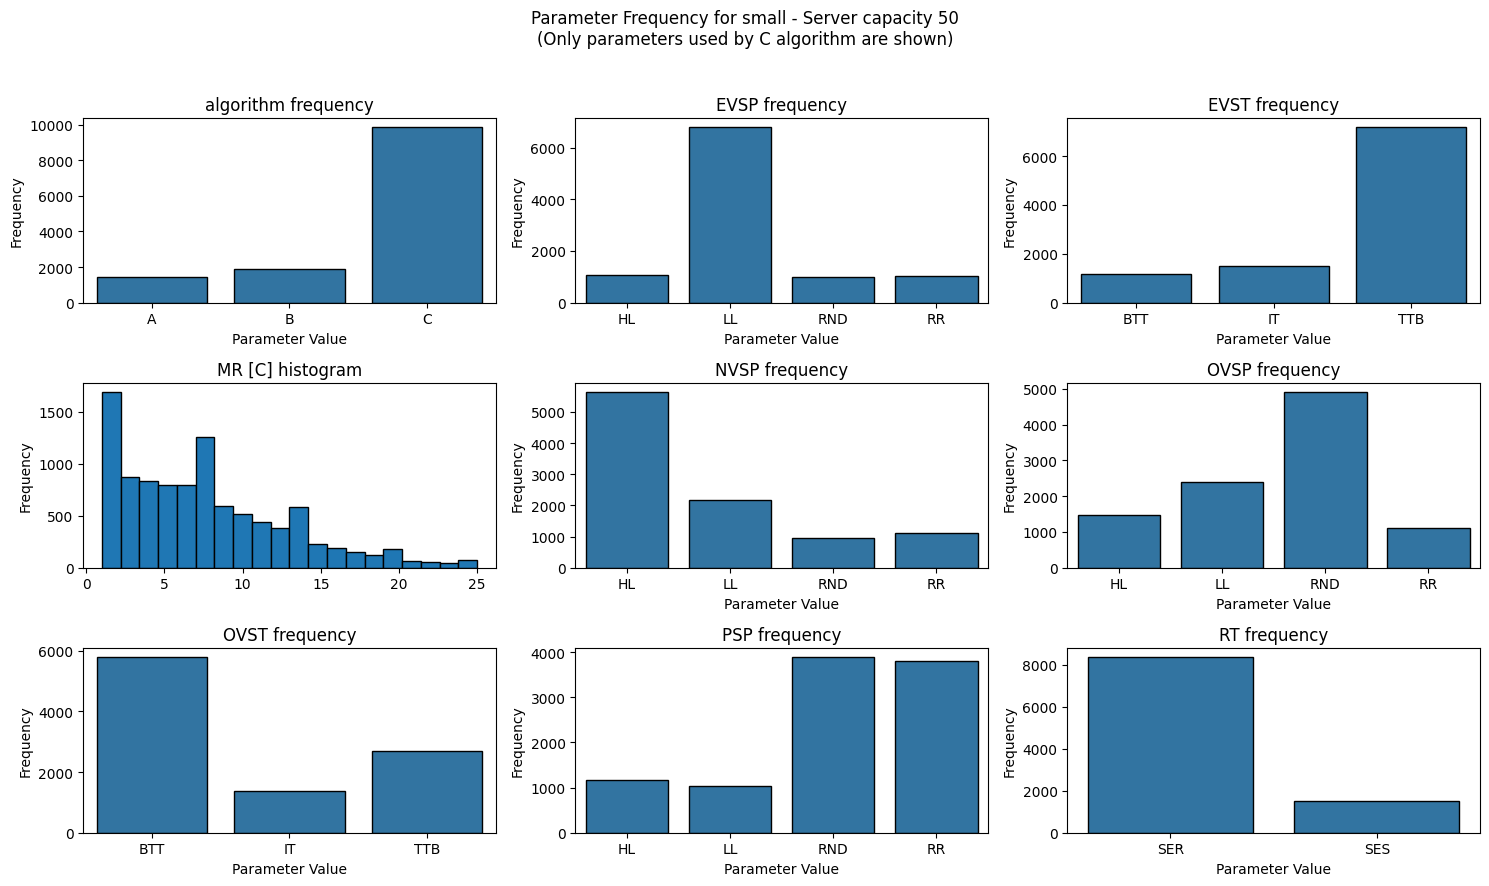

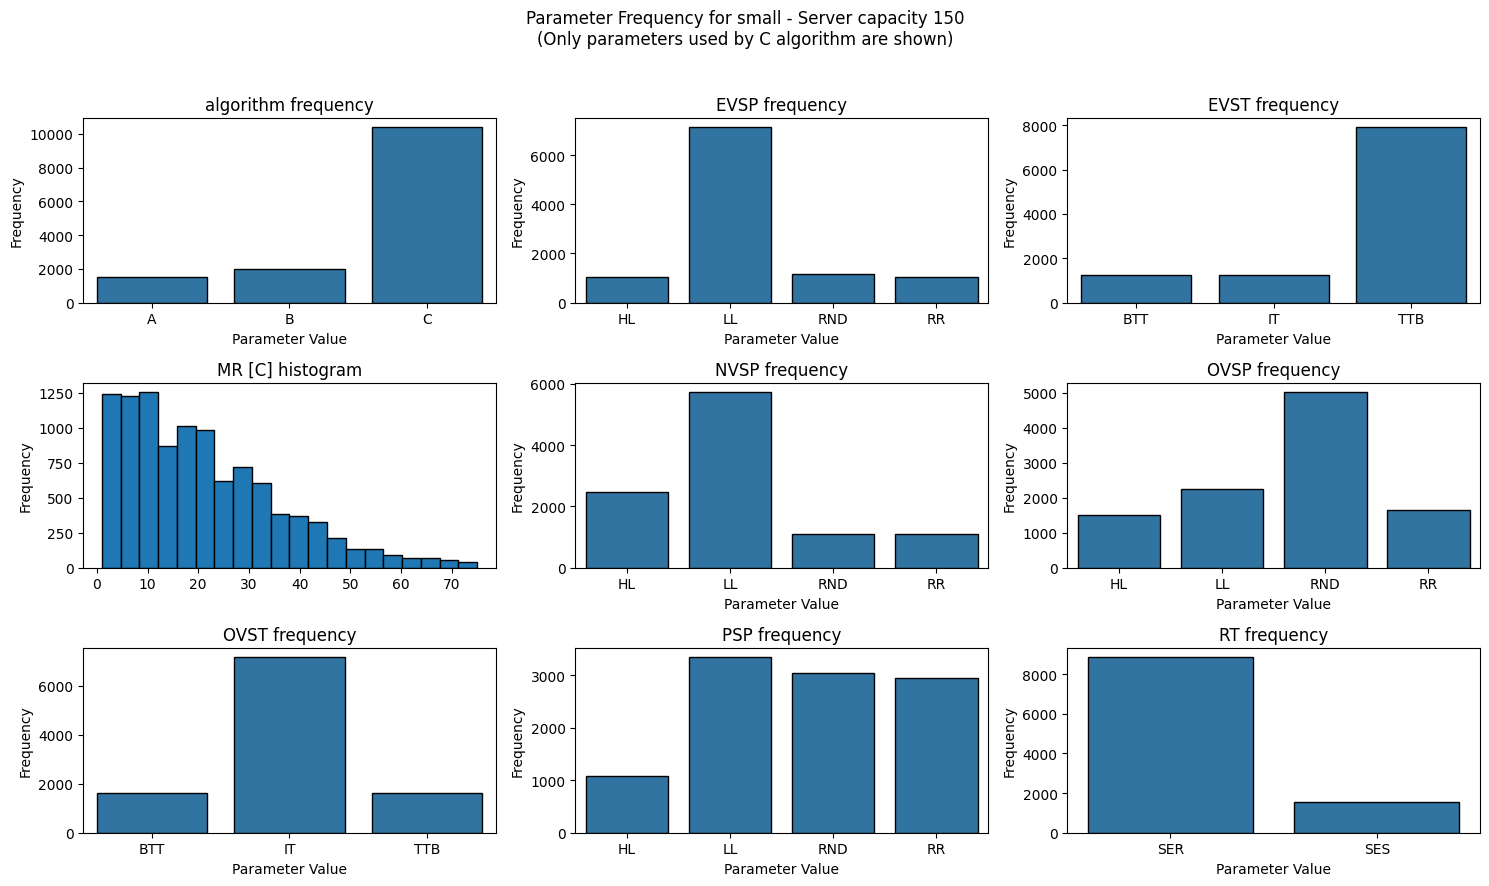

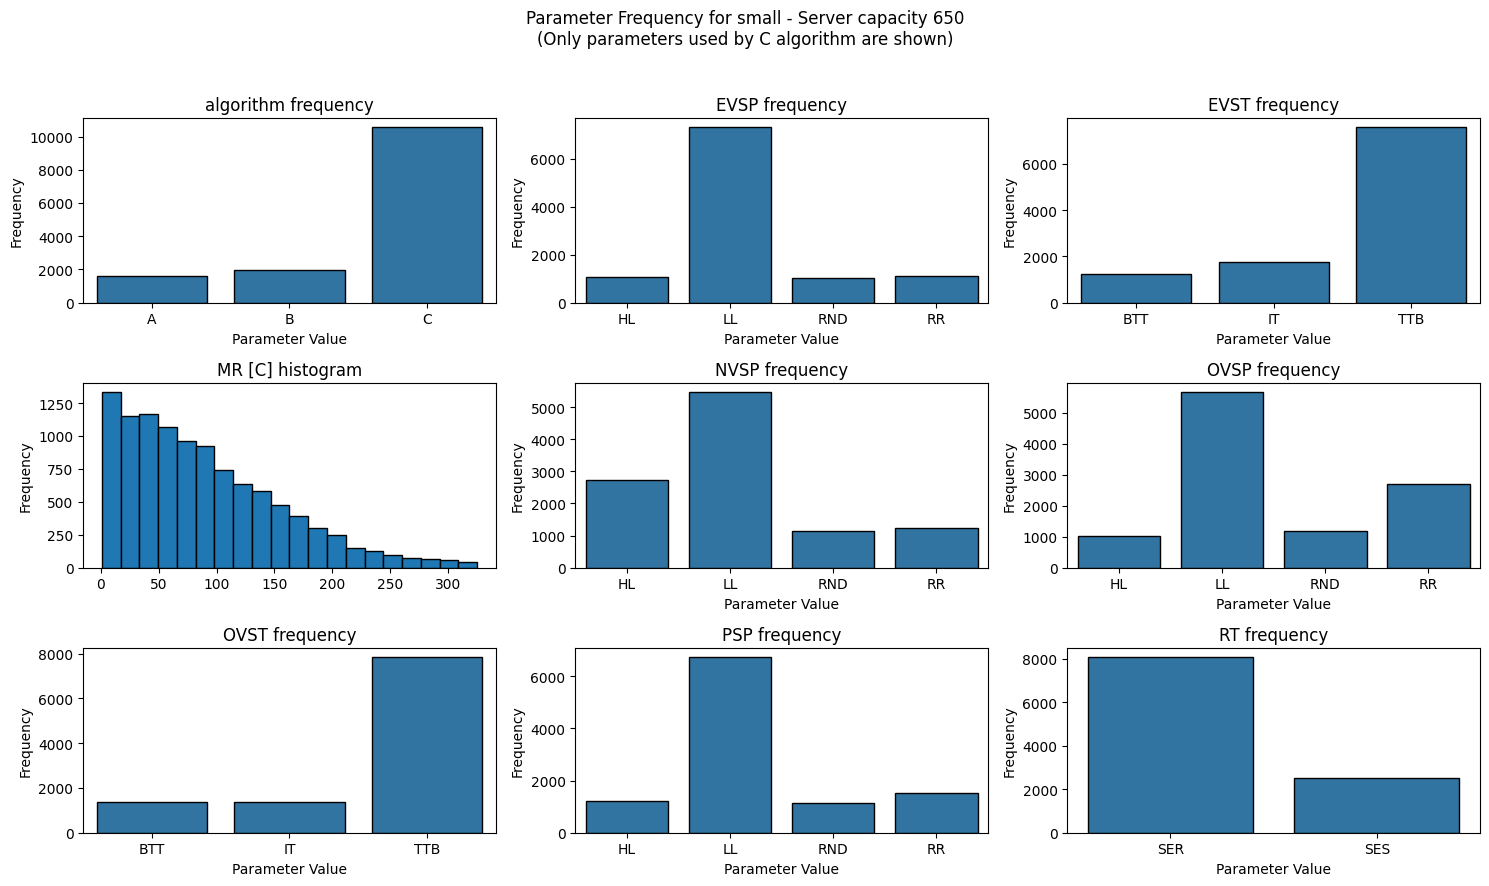

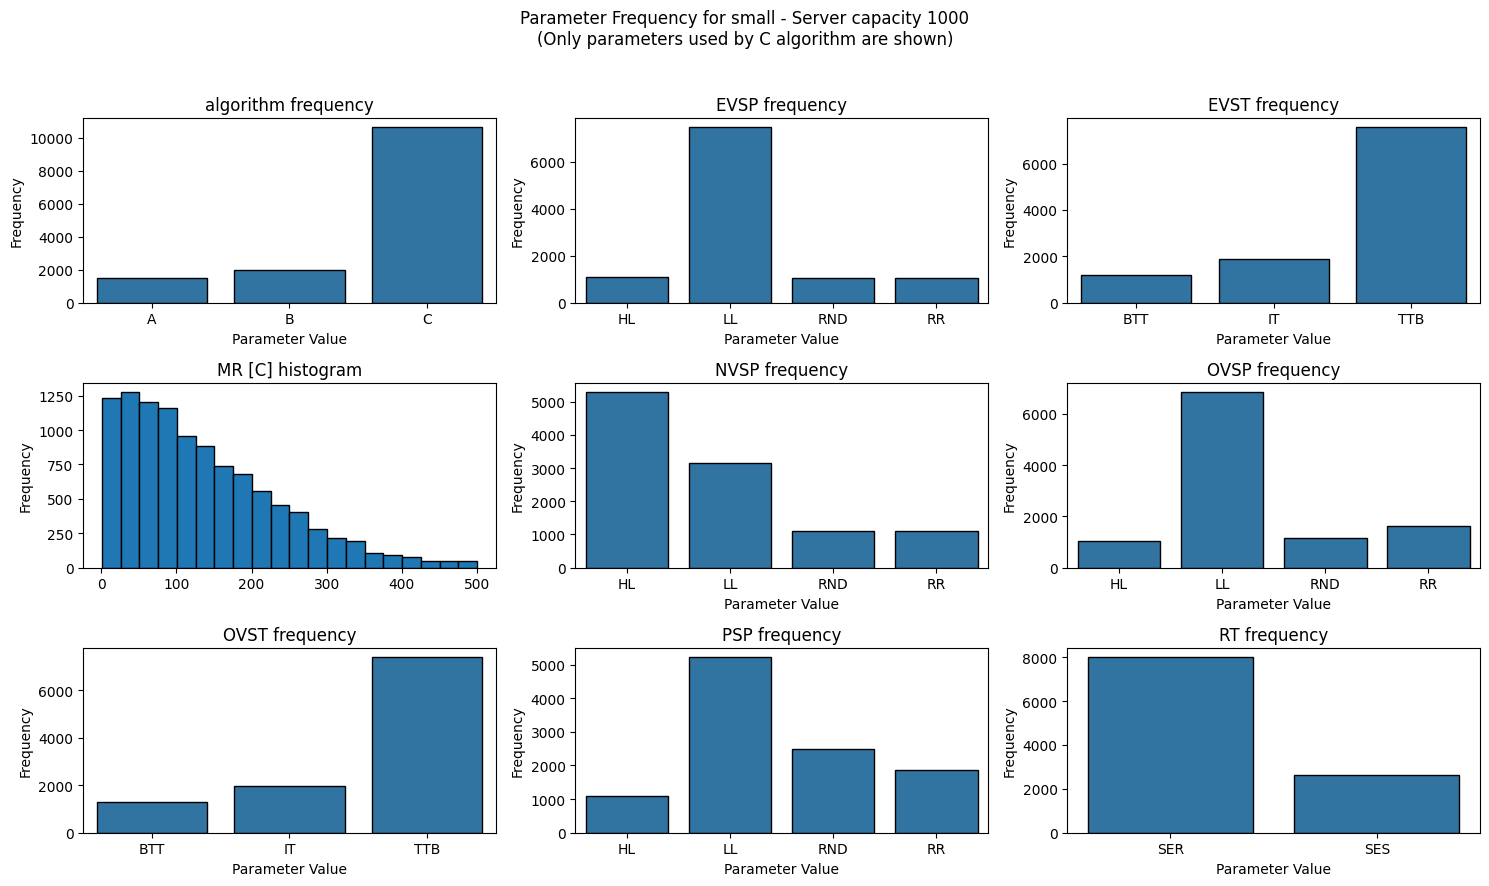

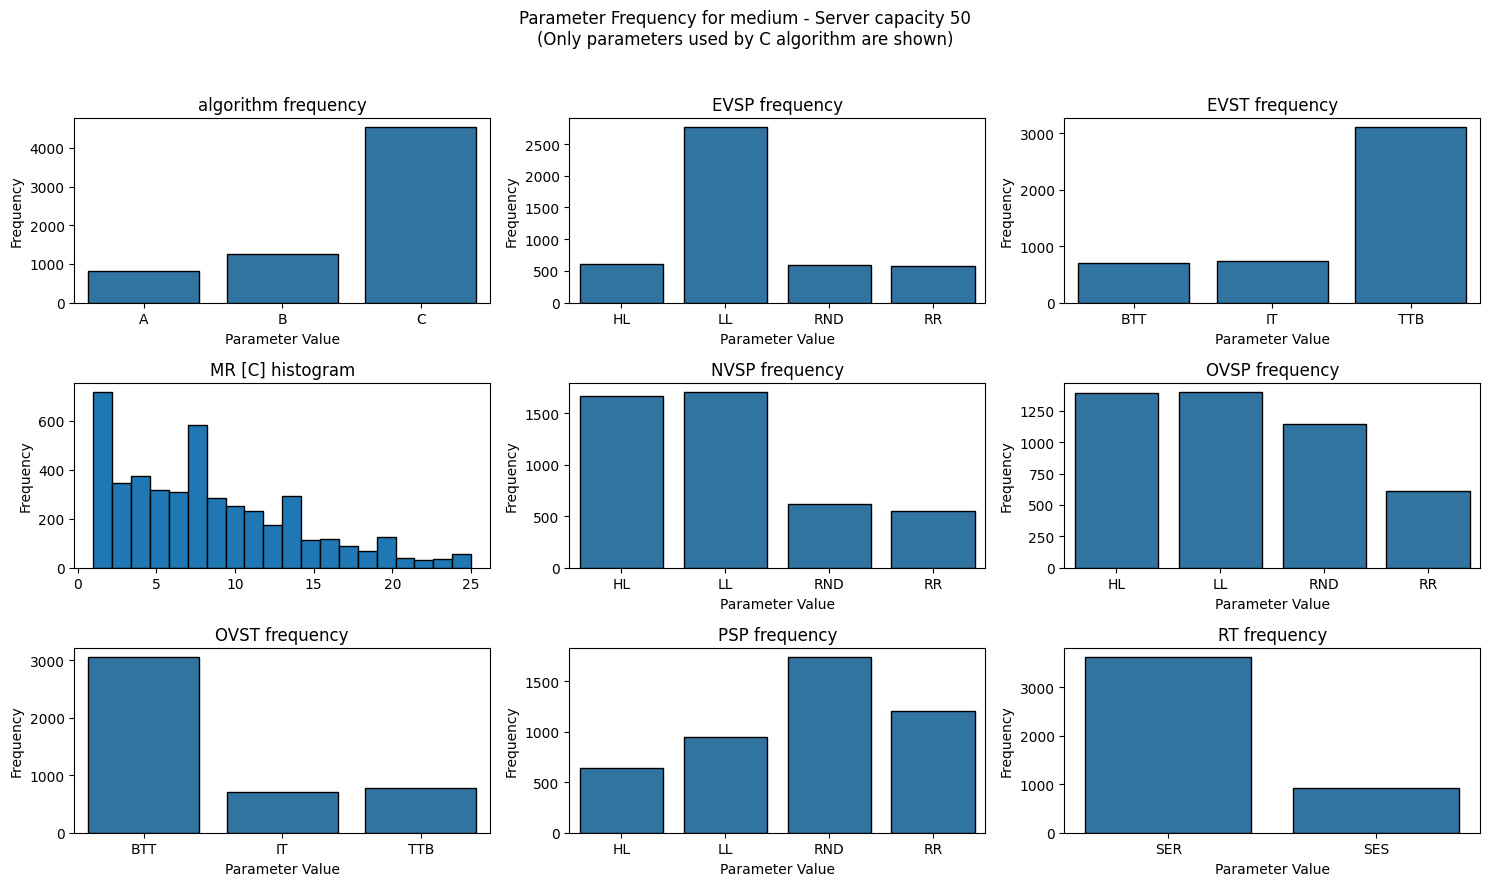

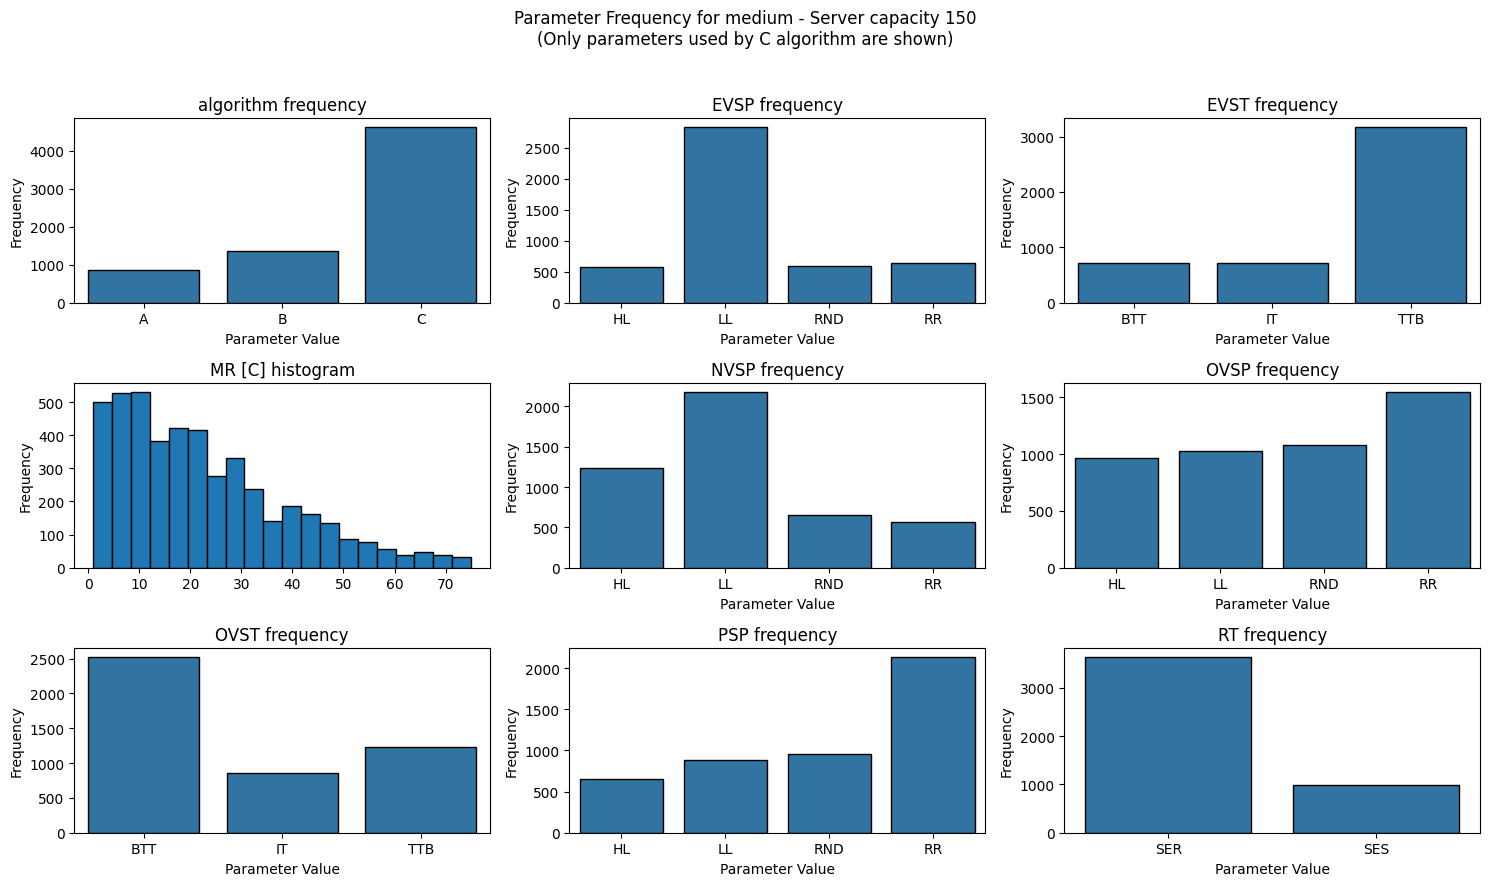

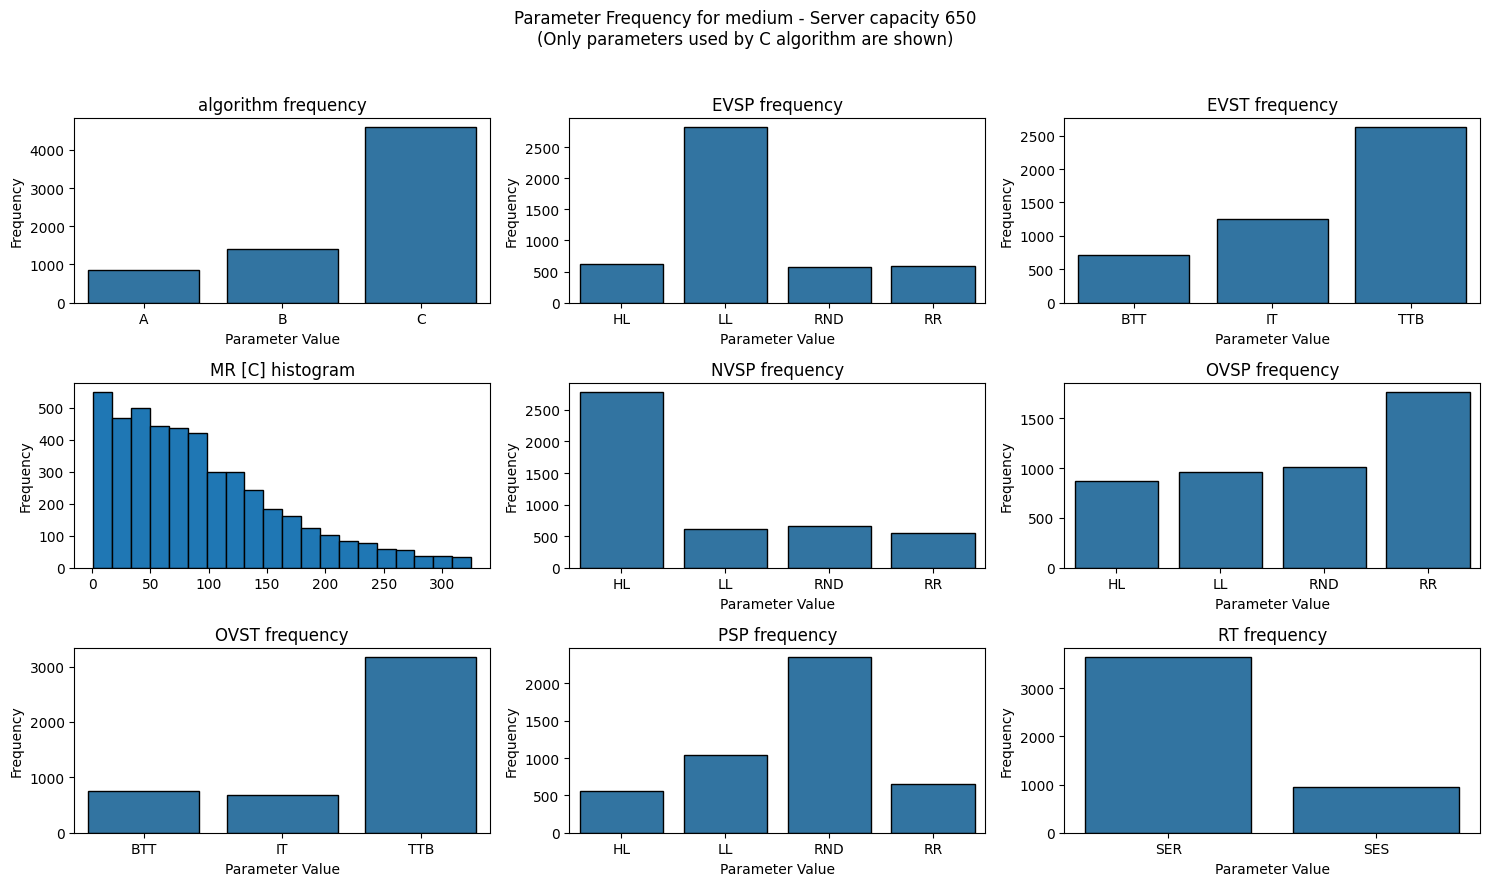

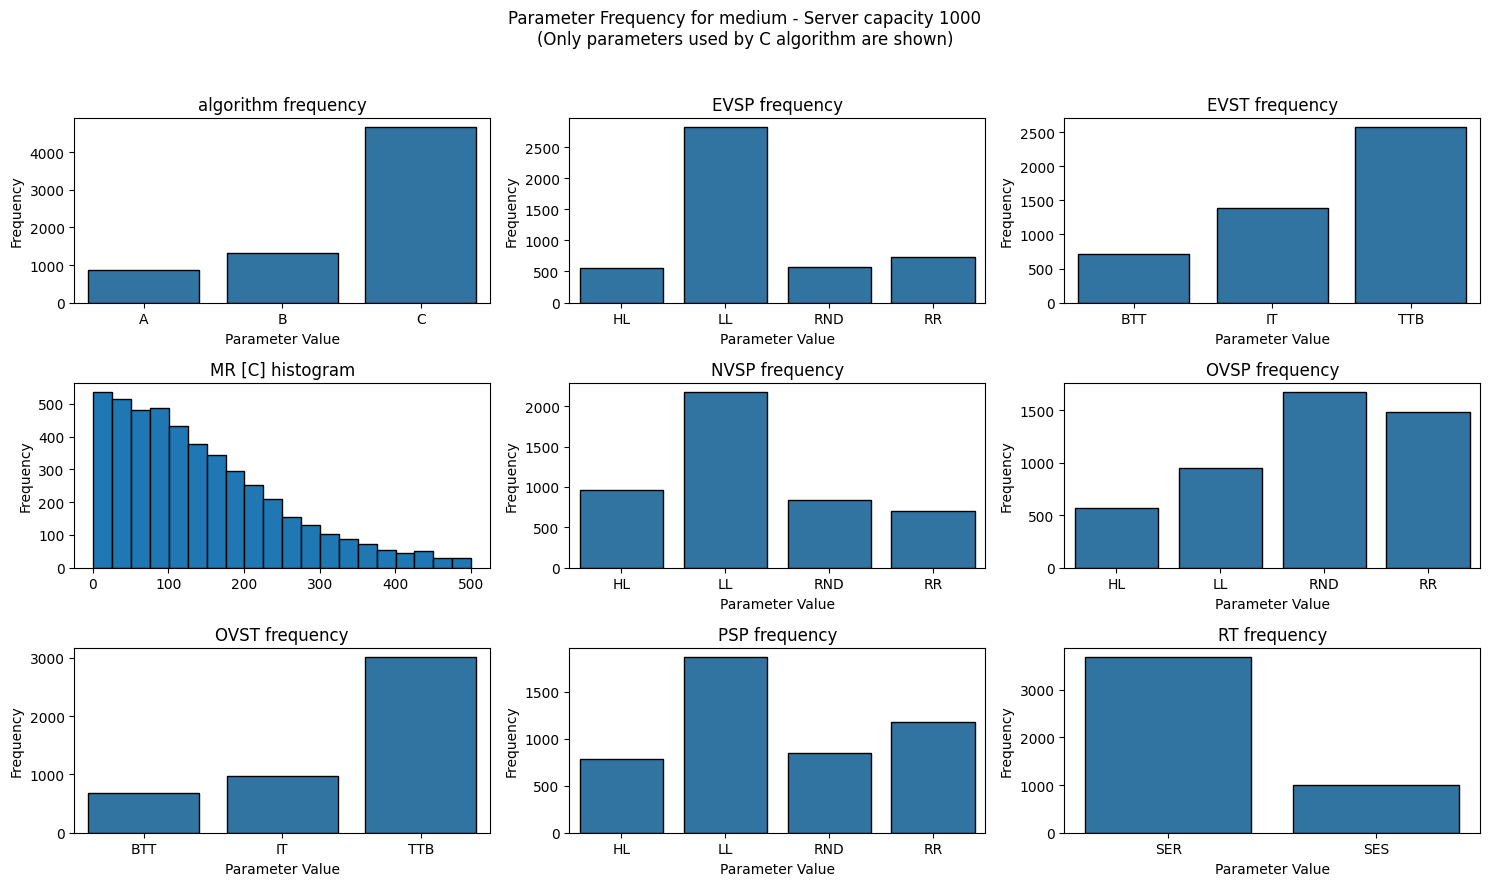

In [13]:
# calculate chosen parameter frequency
def calculate_chosen_parameter_frequency(configs):
    frequency = {}
    for col in configs.columns:
        if col == "algorithm" or col in alg_c_parameters:
            if col not in frequency:
                frequency[col] = {}
            for value in configs[col]:
                if value is None or (isinstance(value, float) and pd.isna(value)):
                    continue
                if isinstance(value, float) and value.is_integer():
                    value = int(value)
                if value not in frequency[col]:
                    frequency[col][value] = 0
                frequency[col][value] += 1
    return frequency


# for every instance type and server capacity, calculate the chosen parameter frequency
chosen_parameter_frequency_map = {}
for instance_type, server_capacities in configs_map.items():
    for server_capacity, config in server_capacities.items():
        if instance_type not in chosen_parameter_frequency_map:
            chosen_parameter_frequency_map[instance_type] = {}
        frequency = calculate_chosen_parameter_frequency(config)
        chosen_parameter_frequency_map[instance_type][server_capacity] = frequency
# for every instance type and server capacity, display the chosen parameter frequency
# Use subplots for every instance type and server capacity
for instance_type, server_capacities in chosen_parameter_frequency_map.items():
    for server_capacity, frequency in server_capacities.items():
        all_params = ["algorithm"] + sorted([p for p in frequency.keys() if p != "algorithm"])
        n_params = len(all_params)
        ncols = 3
        nrows = (n_params - 1 + ncols) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
        fig.suptitle(
            f"Parameter Frequency for {instance_type} - Server capacity {server_capacity}\n(Only parameters used by C algorithm are shown)",
        )
        axes = axes.flatten()
        for idx, param in enumerate(all_params):
            param_values = frequency[param]
            if param_values:
                freq_series = pd.Series(param_values)
                # Check if all keys are ints (or can be safely cast to int)
                try:
                    keys_as_int = [int(k) for k in freq_series.index]
                    is_all_int = all(
                        isinstance(k, int)
                        or (isinstance(k, float) and k.is_integer())
                        for k in freq_series.index
                    )
                except Exception:
                    is_all_int = False
                    freq_series = freq_series.sort_index()
                if is_all_int and len(freq_series) > 1:
                    # Expand the series for histogram plotting
                    expanded = []
                    for k, v in freq_series.items():
                        expanded.extend([int(k)] * v)
                    axes[idx].hist(expanded, bins=20, edgecolor="black")
                    axes[idx].set_title(f"{param} histogram")
                    axes[idx].set_ylabel("Frequency")
                else:
                    sns.barplot(
                        x=freq_series.index.astype(str),
                        y=freq_series.values,
                        ax=axes[idx],
                        edgecolor="black"
                    )
                    axes[idx].set_title(f"{param} frequency")
                    axes[idx].set_xlabel("Parameter Value")
                    axes[idx].set_ylabel("Frequency")
            else:
                axes[idx].set_visible(False)
        for idx in range(len(all_params), len(axes)):
            axes[idx].set_visible(False)
        plt.tight_layout(rect=[0, 0, 1, 0.96])

Text(0.5, 14.722222222222216, 'Server Capacity')

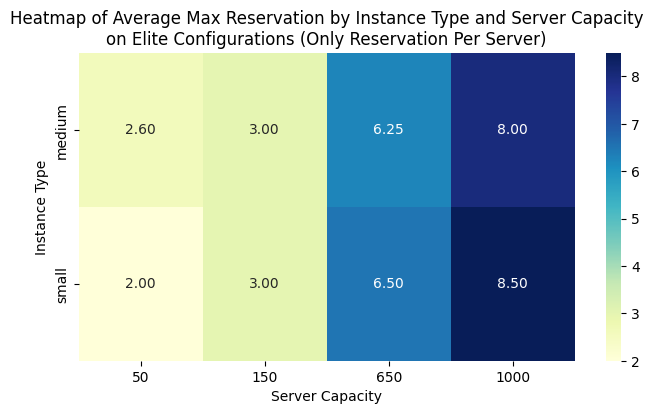

In [7]:
#heatmap of server capacity and max reservation in elite configs
heatmap_data = []
for instance_type, server_capacities in elite_configs_map.items():
    for server_capacity, elite_config in server_capacities.items():
        if "MR [C]" in elite_config.columns:
            heatmap_data.append({
                "Instance Type": instance_type,
                "Server Capacity": server_capacity,
                "Max Reservation": elite_config[elite_config["RT"] == "SER"]["MR [C]"].mean()
            })
        if "MR" in elite_config.columns:
            heatmap_data.append({
                "Instance Type": instance_type,
                "Server Capacity": server_capacity,
                "Max Reservation": elite_config[elite_config["RT"] == "SER"]["MR"].mean()
            })

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_pivot = heatmap_df.pivot(index="Instance Type", columns="Server Capacity", values="Max Reservation")

# Sort columns numerically for correct order in heatmap
sorted_columns = sorted(heatmap_pivot.columns, key=lambda x: int(x))
heatmap_pivot = heatmap_pivot[sorted_columns]

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Average Max Reservation by Instance Type and Server Capacity\non Elite Configurations (Only Reservation Per Server)")
plt.ylabel("Instance Type")
plt.xlabel("Server Capacity")